# Process Transformer V2 Training Notebook

This notebook trains a Process Transformer model to predict:
1. **Next Activity** (Classification)
2. **Next Activity Duration** (Regression)

**V2 Changes:**
- Added explicit `<END>` token to teach the model when cases should terminate
- Class weights to boost END token learning
- Increased training epochs for better convergence
- Comprehensive performance metrics for reporting

In [1]:
!pip install pm4py scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.5 MB/s eta 0:00:00


In [2]:
# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running in Colab, skipping Drive mount.")

import os
WORK_DIR = 'drive/MyDrive/uni/2026_bpso/BPIC17_ProcessTransformer'

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, r2_score
import sys
import os
import json
import time
from collections import defaultdict

# Ensure we can import the local model definition
sys.path.append(WORK_DIR)

try:
    from processtransformer import ProcessTransformer
except ImportError:
    print("Error importing ProcessTransformer. Make sure processtransformer.py is in the current directory.")

## 1. Data Loading

Load the BPIC17 event log from XES format.

In [4]:
import pm4py

# Update this path to your XES file location
XES_PATH = f"{WORK_DIR}/data/eventlog.xes.gz"

# Load event log
log = pm4py.read_xes(XES_PATH)

# Convert to DataFrame
df_raw = pm4py.convert_to_dataframe(log)

# Standardize column names
df_raw = df_raw.rename(columns={
    'case:concept:name': 'case_id',
    'concept:name': 'activity',
    'time:timestamp': 'timestamp',
    'lifecycle:transition': 'lifecycle'
})

print(f"Loaded {len(df_raw)} events from {df_raw['case_id'].nunique()} cases")
print(df_raw.head())

/usr/local/lib/python3.12/dist-packages/pm4py/utils.py:992: UserWarning: Install the optional requirement `rustxes` to import/export files faster.
  warnings.warn("Install the optional requirement `rustxes` to import/export files faster.")


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

Loaded 1202267 events from 31509 cases
        Action org:resource                activity  EventOrigin  \
0      Created       User_1    A_Create Application  Application   
1  statechange       User_1             A_Submitted  Application   
2      Created       User_1          W_Handle leads     Workflow   
3      Deleted       User_1          W_Handle leads     Workflow   
4      Created       User_1  W_Complete application     Workflow   

                 EventID lifecycle               timestamp  \
0  Application_652823628  complete 2016-01-01 09:51:15.304   
1   ApplState_1582051990  complete 2016-01-01 09:51:15.352   
2    Workitem_1298499574  schedule 2016-01-01 09:51:15.774   
3    Workitem_1673366067  withdraw 2016-01-01 09:52:36.392   
4    Workitem_1493664571  schedule 2016-01-01 09:52:36.403   

            case:LoanGoal case:ApplicationType                case_id  \
0  Existing loan takeover           New credit  Application_652823628   
1  Existing loan takeover        

## 2. Data Pipeline & Preprocessing

In [5]:
def preprocess_data_optimized(df):
    """Process raw event log to compute activity durations."""
    # 1. Prepare Data
    if not pd.api.types.is_datetime64_any_dtype(df['timestamp']):
        df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)

    df = df.sort_values(['case_id', 'timestamp'])

    # 2. Extract columns to Numpy arrays for speed
    case_ids = df['case_id'].values
    activities = df['activity'].values
    lifecycles = df['lifecycle'].astype(str)
    timestamps = df['timestamp'].values

    processed_data = []
    current_case = None
    open_activities = {}

    print(f"Processing {len(df)} events using fast iteration...")

    for case, act, lifecycle, ts in zip(case_ids, activities, lifecycles, timestamps):
        if case != current_case:
            current_case = case
            open_activities = {}

        lifecycle_lower = lifecycle.lower()

        if lifecycle_lower == 'start':
            open_activities[act] = ts

        elif lifecycle_lower == 'complete':
            duration = 0.0
            if act in open_activities:
                start_ts = open_activities.pop(act)
                duration = (ts - start_ts) / np.timedelta64(1, 's')

            processed_data.append({
                'case_id': case,
                'activity': act,
                'timestamp': ts,
                'lifecycle': lifecycle,
                'duration': duration
            })

    return pd.DataFrame(processed_data)

df_clean = preprocess_data_optimized(df_raw)
print(f"\nProcessed data: {len(df_clean)} events")
print(df_clean.head())

Processing 1202267 events using fast iteration...

Processed data: 475306 events
                  case_id              activity               timestamp  \
0  Application_1000086665  A_Create Application 2016-08-03 15:57:21.673   
1  Application_1000086665           A_Submitted 2016-08-03 15:57:21.734   
2  Application_1000086665             A_Concept 2016-08-03 15:58:28.299   
3  Application_1000086665            A_Accepted 2016-08-05 13:57:07.419   
4  Application_1000086665        O_Create Offer 2016-08-05 13:59:57.320   

  lifecycle  duration  
0  complete       0.0  
1  complete       0.0  
2  complete       0.0  
3  complete       0.0  
4  complete       0.0  


## 3. Dataset with END Token Support

**Key V2 Change:** We add an explicit `<END>` token at the end of each case sequence.

In [6]:
# Define END token constant
END_TOKEN = "<END>"

class ProcessSequenceDataset(Dataset):
    def __init__(self, df, max_len=50, activity_vocab=None):
        self.max_len = max_len

        # Sort once globally
        df = df.sort_values(['case_id', 'timestamp'])

        # Create vocabulary from activities
        if activity_vocab is None:
            unique_activities = df['activity'].unique().tolist()
            self.vocab = {act: i+1 for i, act in enumerate(unique_activities)}
            self.vocab[END_TOKEN] = len(self.vocab) + 1
        else:
            self.vocab = activity_vocab
            if END_TOKEN not in self.vocab:
                self.vocab[END_TOKEN] = len(self.vocab) + 1

        # Reverse vocab for decoding
        self.idx_to_activity = {v: k for k, v in self.vocab.items()}

        self.end_token_id = self.vocab[END_TOKEN]
        print(f"Vocabulary size: {len(self.vocab)} (including END token at index {self.end_token_id})")

        # Map activities to integers
        df['act_id'] = df['activity'].map(self.vocab).fillna(0).astype(int)

        # Log transform durations
        df['duration_log'] = np.log1p(df['duration'])

        # Group by case and aggregate into lists
        grouped = df.groupby('case_id')
        self.case_activities = grouped['act_id'].agg(list).values
        self.case_durations = grouped['duration_log'].agg(list).values

        # Build samples with END token appended to each case
        self.samples = []
        print(f"Indexing {len(self.case_activities)} cases with END token...")

        for case_idx, (acts, durs) in enumerate(zip(self.case_activities, self.case_durations)):
            acts_with_end = acts + [self.end_token_id]
            durs_with_end = durs + [0.0]

            self.case_activities[case_idx] = acts_with_end
            self.case_durations[case_idx] = durs_with_end

            for i in range(1, len(acts_with_end)):
                self.samples.append((case_idx, i))

        print(f"Dataset ready. Generated {len(self.samples)} training samples.")

        # Calculate END token proportion
        end_samples = sum(1 for case_idx, target_idx in self.samples
                        if self.case_activities[case_idx][target_idx] == self.end_token_id)
        print(f"END token samples: {end_samples} ({100*end_samples/len(self.samples):.1f}% of training data)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        case_idx, target_idx = self.samples[idx]

        full_acts = self.case_activities[case_idx]
        full_durs = self.case_durations[case_idx]

        input_seq = full_acts[:target_idx]
        target_act = full_acts[target_idx]
        target_dur = full_durs[target_idx]

        seq_len = len(input_seq)
        seq_tensor = torch.tensor(input_seq, dtype=torch.long)

        if seq_len < self.max_len:
            pad_size = self.max_len - seq_len
            seq_tensor = torch.cat([torch.zeros(pad_size, dtype=torch.long), seq_tensor])
        else:
            seq_tensor = seq_tensor[-self.max_len:]

        return (
            seq_tensor,
            torch.tensor(target_act, dtype=torch.long),
            torch.tensor(target_dur, dtype=torch.float32)
        )

## 4. Train/Validation Split & DataLoaders

In [7]:
# Configuration
MAX_LEN = 50
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-3
END_TOKEN_WEIGHT = 2.0
VAL_SPLIT = 0.1  # 10% validation

# Create full dataset
full_dataset = ProcessSequenceDataset(df_clean, max_len=MAX_LEN)

# Split indices
all_indices = list(range(len(full_dataset)))
train_indices, val_indices = train_test_split(all_indices, test_size=VAL_SPLIT, random_state=42)

train_dataset = Subset(full_dataset, train_indices)
val_dataset = Subset(full_dataset, val_indices)

print(f"\nTrain samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Vocab size
vocab_size = len(full_dataset.vocab) + 1
print(f"Vocab size for model: {vocab_size}")

Vocabulary size: 25 (including END token at index 25)
Indexing 31509 cases with END token...
Dataset ready. Generated 475306 training samples.
END token samples: 31509 (6.6% of training data)

Train samples: 427775
Val samples: 47531
Vocab size for model: 26


## 5. Model Setup

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = ProcessTransformer(num_activities=vocab_size, max_len=MAX_LEN).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Class weights with higher weight for END token
class_weights = torch.ones(vocab_size)
class_weights[full_dataset.end_token_id] = END_TOKEN_WEIGHT
class_weights = class_weights.to(device)
print(f"END token (index {full_dataset.end_token_id}) weight: {END_TOKEN_WEIGHT}")

criterion_act = nn.CrossEntropyLoss(weight=class_weights)
criterion_dur = nn.L1Loss()

# Count model parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel parameters: {total_params:,} total, {trainable_params:,} trainable")

Using device: cuda
END token (index 25) weight: 2.0

Model parameters: 17,039 total, 17,039 trainable


## 6. Training with Metrics Tracking

In [9]:
# Metrics storage
training_history = {
    'epoch': [],
    'train_loss': [],
    'train_loss_act': [],
    'train_loss_dur': [],
    'val_loss': [],
    'val_loss_act': [],
    'val_loss_dur': [],
    'val_acc_top1': [],
    'val_acc_top3': [],
    'val_acc_top5': [],
    'val_dur_mae': [],
    'val_dur_rmse': [],
    'val_end_acc': [],
}

def train_epoch(model, dataloader, optimizer, crit_act, crit_dur):
    model.train()
    total_loss, total_loss_act, total_loss_dur = 0, 0, 0

    for seq, target_act, target_dur in dataloader:
        seq = seq.to(device)
        target_act = target_act.to(device)
        target_dur = target_dur.to(device)

        optimizer.zero_grad()
        pred_act, pred_dur = model(seq)

        loss_act = crit_act(pred_act, target_act)
        loss_dur = crit_dur(pred_dur.squeeze(), target_dur)
        loss = loss_act + loss_dur

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_loss_act += loss_act.item()
        total_loss_dur += loss_dur.item()

    n = len(dataloader)
    return total_loss / n, total_loss_act / n, total_loss_dur / n

@torch.no_grad()
def validate(model, dataloader, crit_act, crit_dur, end_token_id):
    model.eval()
    total_loss, total_loss_act, total_loss_dur = 0, 0, 0

    all_preds = []
    all_targets = []
    all_pred_durs = []
    all_target_durs = []
    all_topk_preds = []

    for seq, target_act, target_dur in dataloader:
        seq = seq.to(device)
        target_act = target_act.to(device)
        target_dur = target_dur.to(device)

        pred_act, pred_dur = model(seq)

        loss_act = crit_act(pred_act, target_act)
        loss_dur = crit_dur(pred_dur.squeeze(), target_dur)
        loss = loss_act + loss_dur

        total_loss += loss.item()
        total_loss_act += loss_act.item()
        total_loss_dur += loss_dur.item()

        all_preds.extend(pred_act.argmax(dim=1).cpu().numpy())
        all_targets.extend(target_act.cpu().numpy())
        all_pred_durs.extend(pred_dur.squeeze().cpu().numpy())
        all_target_durs.extend(target_dur.cpu().numpy())

        topk = torch.topk(pred_act, k=5, dim=1).indices.cpu().numpy()
        all_topk_preds.extend(topk)

    n = len(dataloader)

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    all_pred_durs = np.array(all_pred_durs)
    all_target_durs = np.array(all_target_durs)
    all_topk_preds = np.array(all_topk_preds)

    # Activity metrics
    acc_top1 = accuracy_score(all_targets, all_preds)
    acc_top3 = np.mean([t in topk[:3] for t, topk in zip(all_targets, all_topk_preds)])
    acc_top5 = np.mean([t in topk for t, topk in zip(all_targets, all_topk_preds)])

    # Duration metrics
    dur_mae = np.mean(np.abs(all_pred_durs - all_target_durs))
    dur_rmse = np.sqrt(np.mean((all_pred_durs - all_target_durs) ** 2))

    # END token accuracy
    end_mask = all_targets == end_token_id
    end_acc = accuracy_score(all_targets[end_mask], all_preds[end_mask]) if end_mask.sum() > 0 else 0.0

    return {
        'loss': total_loss / n,
        'loss_act': total_loss_act / n,
        'loss_dur': total_loss_dur / n,
        'acc_top1': acc_top1,
        'acc_top3': acc_top3,
        'acc_top5': acc_top5,
        'dur_mae': dur_mae,
        'dur_rmse': dur_rmse,
        'end_acc': end_acc,
    }

In [10]:
# Training loop
print(f"Starting training for {EPOCHS} epochs...")
print("=" * 100)
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>10} | {'Val Acc@1':>10} | {'Val Acc@3':>10} | {'END Acc':>10} | {'Dur MAE':>10}")
print("-" * 100)

best_val_loss = float('inf')
training_start = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    # Train
    train_loss, train_loss_act, train_loss_dur = train_epoch(
        model, train_loader, optimizer, criterion_act, criterion_dur
    )

    # Validate
    val_metrics = validate(
        model, val_loader, criterion_act, criterion_dur, full_dataset.end_token_id
    )

    # Store history
    training_history['epoch'].append(epoch + 1)
    training_history['train_loss'].append(train_loss)
    training_history['train_loss_act'].append(train_loss_act)
    training_history['train_loss_dur'].append(train_loss_dur)
    training_history['val_loss'].append(val_metrics['loss'])
    training_history['val_loss_act'].append(val_metrics['loss_act'])
    training_history['val_loss_dur'].append(val_metrics['loss_dur'])
    training_history['val_acc_top1'].append(val_metrics['acc_top1'])
    training_history['val_acc_top3'].append(val_metrics['acc_top3'])
    training_history['val_acc_top5'].append(val_metrics['acc_top5'])
    training_history['val_dur_mae'].append(val_metrics['dur_mae'])
    training_history['val_dur_rmse'].append(val_metrics['dur_rmse'])
    training_history['val_end_acc'].append(val_metrics['end_acc'])

    # Print progress
    print(f"{epoch+1:>5} | {train_loss:>10.4f} | {val_metrics['loss']:>10.4f} | "
          f"{val_metrics['acc_top1']*100:>9.2f}% | {val_metrics['acc_top3']*100:>9.2f}% | "
          f"{val_metrics['end_acc']*100:>9.2f}% | {val_metrics['dur_mae']:>10.4f}")

    # Save best model
    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        torch.save(model.state_dict(), 'model_best.pth')

training_time = time.time() - training_start
print("=" * 100)
print(f"Training complete! Total time: {training_time/60:.1f} minutes")

Starting training for 30 epochs...
Epoch | Train Loss |   Val Loss |  Val Acc@1 |  Val Acc@3 |    END Acc |    Dur MAE
----------------------------------------------------------------------------------------------------
    1 |     1.2296 |     1.1183 |     80.41% |     97.74% |     98.73% |     0.6565
    2 |     1.1189 |     1.1183 |     80.39% |     97.75% |     98.99% |     0.6611
    3 |     1.1101 |     1.1028 |     80.48% |     97.83% |     99.24% |     0.6509
    4 |     1.1027 |     1.1043 |     80.46% |     97.83% |     97.98% |     0.6545
    5 |     1.0993 |     1.0982 |     80.73% |     97.87% |     99.59% |     0.6505
    6 |     1.0960 |     1.0908 |     80.53% |     97.97% |     99.24% |     0.6464
    7 |     1.0983 |     1.0961 |     80.76% |     97.95% |     98.32% |     0.6552
    8 |     1.0968 |     1.0926 |     80.49% |     97.94% |     98.99% |     0.6511
    9 |     1.0943 |     1.0914 |     80.59% |     97.98% |     99.56% |     0.6482
   10 |     1.0935 |    

## 7. Final Model Evaluation & Metrics Report

In [11]:
# Load best model for final evaluation
model.load_state_dict(torch.load('model_best.pth'))
print("Loaded best model checkpoint")

Loaded best model checkpoint


In [12]:
@torch.no_grad()
def comprehensive_evaluation(model, dataloader, dataset, device):
    """Generate comprehensive metrics for reporting."""
    model.eval()

    all_preds = []
    all_targets = []
    all_pred_durs = []
    all_target_durs = []
    all_probs = []

    for seq, target_act, target_dur in dataloader:
        seq = seq.to(device)
        pred_act, pred_dur = model(seq)

        probs = torch.softmax(pred_act, dim=1)

        all_preds.extend(pred_act.argmax(dim=1).cpu().numpy())
        all_targets.extend(target_act.numpy())
        all_pred_durs.extend(pred_dur.squeeze().cpu().numpy())
        all_target_durs.extend(target_dur.numpy())
        all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    all_pred_durs = np.array(all_pred_durs)
    all_target_durs = np.array(all_target_durs)
    all_probs = np.array(all_probs)

    # Top-k accuracy
    topk_preds = np.argsort(-all_probs, axis=1)
    acc_top1 = np.mean(all_targets == topk_preds[:, 0])
    acc_top3 = np.mean([t in preds[:3] for t, preds in zip(all_targets, topk_preds)])
    acc_top5 = np.mean([t in preds[:5] for t, preds in zip(all_targets, topk_preds)])

    # Precision, Recall, F1
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_targets, all_preds, average='macro', zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_targets, all_preds, average='weighted', zero_division=0
    )

    # Duration metrics
    dur_mae_log = np.mean(np.abs(all_pred_durs - all_target_durs))
    dur_rmse_log = np.sqrt(np.mean((all_pred_durs - all_target_durs) ** 2))
    dur_r2 = r2_score(all_target_durs, all_pred_durs)

    # Convert back to original scale
    pred_durs_orig = np.expm1(all_pred_durs)
    target_durs_orig = np.expm1(all_target_durs)
    dur_mae_seconds = np.mean(np.abs(pred_durs_orig - target_durs_orig))
    dur_rmse_seconds = np.sqrt(np.mean((pred_durs_orig - target_durs_orig) ** 2))

    # END token metrics
    end_token_id = dataset.end_token_id
    end_mask = all_targets == end_token_id
    non_end_mask = all_targets != end_token_id

    end_precision = np.sum((all_preds == end_token_id) & end_mask) / max(np.sum(all_preds == end_token_id), 1)
    end_recall = np.sum((all_preds == end_token_id) & end_mask) / max(np.sum(end_mask), 1)
    end_f1 = 2 * end_precision * end_recall / max(end_precision + end_recall, 1e-8)

    non_end_acc = accuracy_score(all_targets[non_end_mask], all_preds[non_end_mask]) if non_end_mask.sum() > 0 else 0

    # Per-activity accuracy
    activity_acc = {}
    for act_id in np.unique(all_targets):
        mask = all_targets == act_id
        if mask.sum() >= 10:
            acc = accuracy_score(all_targets[mask], all_preds[mask])
            act_name = dataset.idx_to_activity.get(act_id, f"ID_{act_id}")
            activity_acc[act_name] = {'accuracy': acc, 'support': int(mask.sum())}

    return {
        'activity_classification': {
            'accuracy_top1': acc_top1,
            'accuracy_top3': acc_top3,
            'accuracy_top5': acc_top5,
            'precision_macro': precision_macro,
            'recall_macro': recall_macro,
            'f1_macro': f1_macro,
            'precision_weighted': precision_weighted,
            'recall_weighted': recall_weighted,
            'f1_weighted': f1_weighted,
        },
        'duration_regression': {
            'mae_log_scale': dur_mae_log,
            'rmse_log_scale': dur_rmse_log,
            'r2_log_scale': dur_r2,
            'mae_seconds': dur_mae_seconds,
            'rmse_seconds': dur_rmse_seconds,
        },
        'end_token': {
            'precision': end_precision,
            'recall': end_recall,
            'f1': end_f1,
            'support': int(end_mask.sum()),
        },
        'non_end_accuracy': non_end_acc,
        'per_activity_accuracy': activity_acc,
        'total_samples': len(all_targets),
    }

# Run evaluation
final_metrics = comprehensive_evaluation(model, val_loader, full_dataset, device)

In [13]:
# Print formatted report
print("\n" + "=" * 70)
print("           FINAL MODEL PERFORMANCE REPORT")
print("=" * 70)

print("\n## Activity Prediction (Classification)")
print("-" * 50)
act = final_metrics['activity_classification']
print(f"  Top-1 Accuracy:     {act['accuracy_top1']*100:>6.2f}%")
print(f"  Top-3 Accuracy:     {act['accuracy_top3']*100:>6.2f}%")
print(f"  Top-5 Accuracy:     {act['accuracy_top5']*100:>6.2f}%")
print(f"  Precision (macro):  {act['precision_macro']*100:>6.2f}%")
print(f"  Recall (macro):     {act['recall_macro']*100:>6.2f}%")
print(f"  F1 Score (macro):   {act['f1_macro']*100:>6.2f}%")
print(f"  F1 Score (weighted):{act['f1_weighted']*100:>6.2f}%")

print("\n## Duration Prediction (Regression)")
print("-" * 50)
dur = final_metrics['duration_regression']
print(f"  MAE (log scale):    {dur['mae_log_scale']:>8.4f}")
print(f"  RMSE (log scale):   {dur['rmse_log_scale']:>8.4f}")
print(f"  R² (log scale):     {dur['r2_log_scale']:>8.4f}")
print(f"  MAE (seconds):      {dur['mae_seconds']:>8.1f}")
print(f"  RMSE (seconds):     {dur['rmse_seconds']:>8.1f}")

print("\n## END Token Prediction")
print("-" * 50)
end = final_metrics['end_token']
print(f"  Precision:          {end['precision']*100:>6.2f}%")
print(f"  Recall:             {end['recall']*100:>6.2f}%")
print(f"  F1 Score:           {end['f1']*100:>6.2f}%")
print(f"  Support:            {end['support']:>6d} samples")

print("\n## Additional Metrics")
print("-" * 50)
print(f"  Non-END Accuracy:   {final_metrics['non_end_accuracy']*100:>6.2f}%")
print(f"  Total Val Samples:  {final_metrics['total_samples']:>6d}")

print("\n## Top 10 Per-Activity Accuracy")
print("-" * 50)
sorted_acts = sorted(final_metrics['per_activity_accuracy'].items(),
                     key=lambda x: x[1]['support'], reverse=True)[:10]
for act_name, metrics in sorted_acts:
    print(f"  {act_name[:35]:<35} {metrics['accuracy']*100:>5.1f}%  (n={metrics['support']})")

print("\n" + "=" * 70)


           FINAL MODEL PERFORMANCE REPORT

## Activity Prediction (Classification)
--------------------------------------------------
  Top-1 Accuracy:      80.99%
  Top-3 Accuracy:      98.09%
  Top-5 Accuracy:      99.79%
  Precision (macro):   72.58%
  Recall (macro):      61.14%
  F1 Score (macro):    59.86%
  F1 Score (weighted): 77.99%

## Duration Prediction (Regression)
--------------------------------------------------
  MAE (log scale):      0.6461
  RMSE (log scale):     2.4763
  R² (log scale):       0.0483
  MAE (seconds):        9222.5
  RMSE (seconds):     109427.3

## END Token Prediction
--------------------------------------------------
  Precision:           85.60%
  Recall:              99.27%
  F1 Score:            91.93%
  Support:              3162 samples

## Additional Metrics
--------------------------------------------------
  Non-END Accuracy:    79.69%
  Total Val Samples:   47531

## Top 10 Per-Activity Accuracy
-------------------------------------------

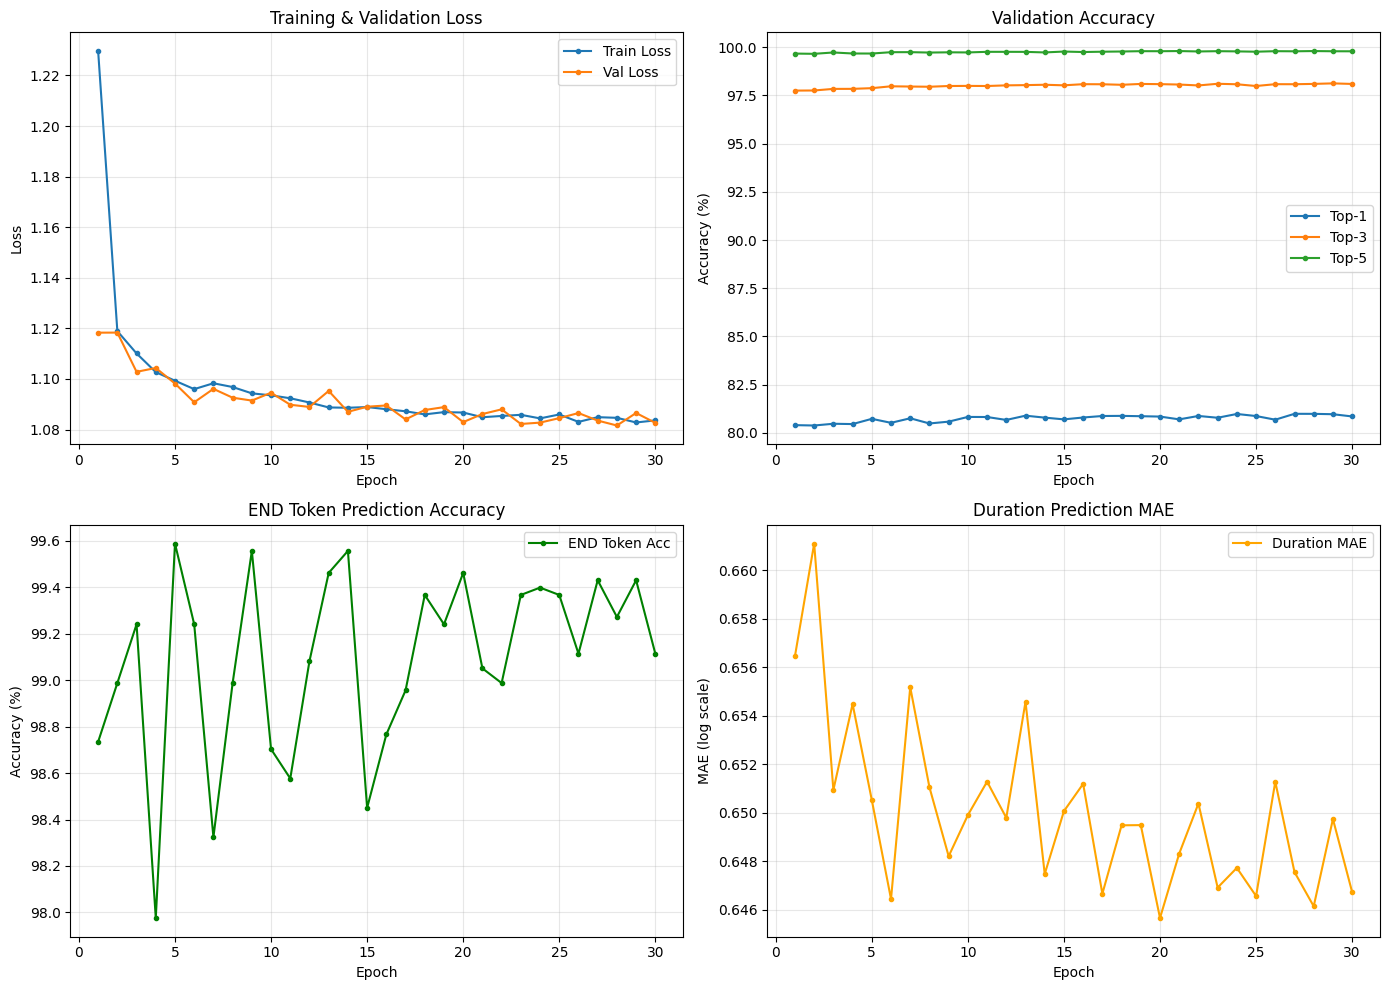

Saved training_curves.png


In [14]:
# Plot training curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss curves
ax = axes[0, 0]
ax.plot(training_history['epoch'], training_history['train_loss'], label='Train Loss', marker='.')
ax.plot(training_history['epoch'], training_history['val_loss'], label='Val Loss', marker='.')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy curves
ax = axes[0, 1]
ax.plot(training_history['epoch'], [x*100 for x in training_history['val_acc_top1']], label='Top-1', marker='.')
ax.plot(training_history['epoch'], [x*100 for x in training_history['val_acc_top3']], label='Top-3', marker='.')
ax.plot(training_history['epoch'], [x*100 for x in training_history['val_acc_top5']], label='Top-5', marker='.')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Validation Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# END token accuracy
ax = axes[1, 0]
ax.plot(training_history['epoch'], [x*100 for x in training_history['val_end_acc']],
        label='END Token Acc', marker='.', color='green')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('END Token Prediction Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# Duration MAE
ax = axes[1, 1]
ax.plot(training_history['epoch'], training_history['val_dur_mae'], label='Duration MAE', marker='.', color='orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (log scale)')
ax.set_title('Duration Prediction MAE')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved training_curves.png")

## 8. Export Model, Vocabulary, and Metrics

In [17]:
# Save final model (use best checkpoint)
import shutil
shutil.copy('model_best.pth', 'model.pth')
print("Saved model.pth (best checkpoint)")

# Save vocabulary
with open('vocab.json', 'w') as f:
    json.dump(full_dataset.vocab, f, indent=2)
print(f"Saved vocab.json with {len(full_dataset.vocab)} entries")

# Helper to convert numpy types to Python native types
def convert_to_serializable(obj):
    if isinstance(obj, (np.floating, np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.integer, np.int32, np.int64)):
        return int(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(i) for i in obj]
    return obj

# Save training history
with open('training_history.json', 'w') as f:
    json.dump(convert_to_serializable(training_history), f, indent=2)
print("Saved training_history.json")

# Save final metrics
with open('final_metrics.json', 'w') as f:
    json.dump(convert_to_serializable(final_metrics), f, indent=2)
print("Saved final_metrics.json")

# Verify END token
assert END_TOKEN in full_dataset.vocab, "END token missing!"
print(f"\nVerified: END token '{END_TOKEN}' at index {full_dataset.vocab[END_TOKEN]}")

Saved model.pth (best checkpoint)
Saved vocab.json with 25 entries
Saved training_history.json
Saved final_metrics.json

Verified: END token '<END>' at index 25


In [16]:
from huggingface_hub import HfApi, create_repo
import os

HF_TOKEN = os.environ.get("HF_TOKEN")  # or paste directly
repo_id = "lgk03/process-transformer-bpic17"

create_repo(repo_id, token=HF_TOKEN, exist_ok=True)

api = HfApi()

files_to_upload = [
    ("model.pth", "model.pth"),
    ("vocab.json", "vocab.json"),
    ("training_history.json", "training_history.json"),
    ("final_metrics.json", "final_metrics.json"),
    ("training_curves.png", "training_curves.png"),
    (f"{WORK_DIR}/processtransformer.py", "processtransformer.py"),
]

for local_path, repo_path in files_to_upload:
    try:
        api.upload_file(
            path_or_fileobj=local_path,
            path_in_repo=repo_path,
            repo_id=repo_id,
            token=HF_TOKEN,
        )
        print(f"Uploaded {repo_path}")
    except Exception as e:
        print(f"Failed to upload {local_path}: {e}")

print(f"\nDone! https://huggingface.co/{repo_id}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  model.pth                   : 100%|##########| 75.6kB / 75.6kB            

Uploaded model.pth
Uploaded vocab.json
Uploaded training_history.json
Failed to upload final_metrics.json: Provided path: 'final_metrics.json' is not a file on the local file system


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  training_curves.png         : 100%|##########|  251kB /  251kB            

Uploaded training_curves.png


No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded processtransformer.py

Done! https://huggingface.co/lgk03/process-transformer-bpic17


## 9. Inference Code Update

After retraining, update your inference code:

```python
END_TOKEN = "<END>"
END_TOKEN_ID = vocab.get(END_TOKEN)

# In generation loop:
if predicted_activity_id == END_TOKEN_ID:
    break  # Natural termination
```